<a href="https://colab.research.google.com/github/Sundharamoorthi0105/Blinkit-Analysis/blob/main/Student_Placement_Skills.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_squared_error
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

In [ ]:
from google.colab import files
import io

print("Please upload the 'Student_Placement_Skills_2025.csv' file.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
    # Assuming the user uploads the correct file, we can proceed to read it.
    # If the file name is different, the user will need to adjust the pd.read_csv line accordingly.

df = pd.read_csv(io.BytesIO(uploaded['Student_Placement_Skills_2025.csv']))


Please upload the 'Student_Placement_Skills_2025.csv' file.


Saving Student_Placement_Skills_2025.csv to Student_Placement_Skills_2025.csv
User uploaded file "Student_Placement_Skills_2025.csv" with length 33801 bytes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    int64  
 1   Gender                          600 non-null    object 
 2   Age                             600 non-null    int64  
 3   Degree                          600 non-null    object 
 4   CGPA                            600 non-null    float64
 5   Internships_Count               600 non-null    int64  
 6   Projects_Count                  600 non-null    int64  
 7   Certifications_Count            600 non-null    int64  
 8   Technical_Skills_Score_100      600 non-null    int64  
 9   Communication_Skills_Score_100  600 non-null    int64  
 10  Aptitude_Test_Score_100         600 non-null    int64  
 11  Placement_Offer                 600 non-null    object 
 12  Salary_Offered_USD              600 

In [ ]:
top5 = df['Salary_Offered_USD'].nlargest(5)
print(top5)


181    19998.13
402    19895.36
412    19894.46
532    19852.10
581    19832.51
Name: Salary_Offered_USD, dtype: float64


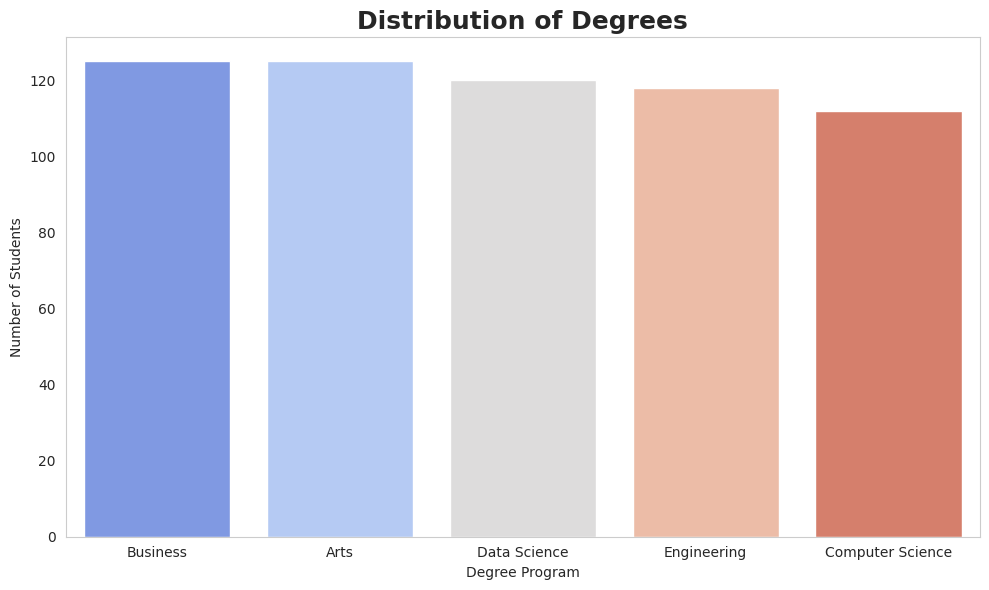

In [ ]:
degree_counts = df['Degree'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(
    x=degree_counts.index,
    y=degree_counts.values,
    hue=degree_counts.index,
    palette='coolwarm',
    legend=False
)
plt.title('Distribution of Degrees', fontsize=18, weight='bold')
plt.xlabel('Degree Program',)
plt.ylabel('Number of Students')
# plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()


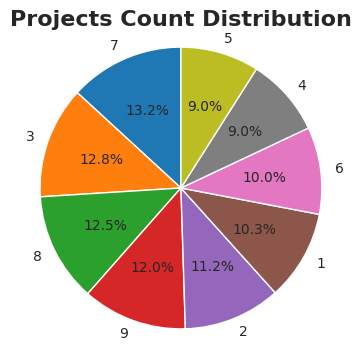

In [ ]:
project_counts = df['Projects_Count'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(project_counts, labels=project_counts.index, autopct='%1.1f%%', startangle=90,)
plt.title('Projects Count Distribution', fontsize=16, weight='bold')
plt.axis('equal')
plt.show()

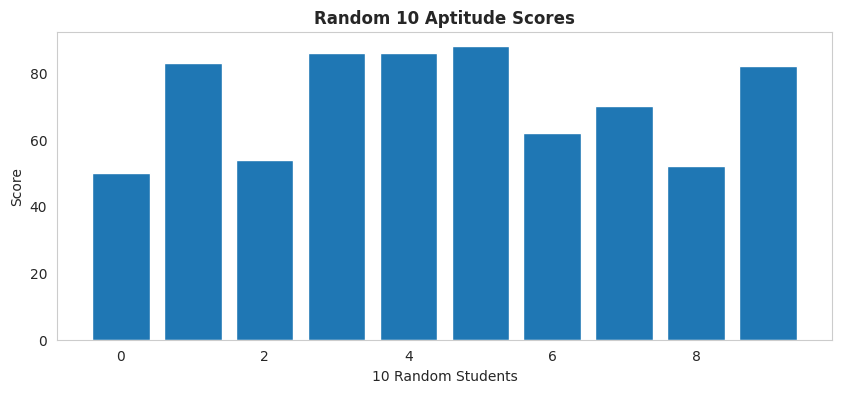

In [ ]:
mix10 = df.sample(10)
plt.figure(figsize=(10,4))
plt.bar(range(10), mix10['Aptitude_Test_Score_100'])
plt.title('Random 10 Aptitude Scores', weight='bold')
plt.xlabel('10 Random Students')
plt.ylabel('Score')
plt.grid(False)
plt.show()



In [ ]:
df["Degree"].value_counts().sort_index()


,count
Degree,
Arts,125
Business,125
Computer Science,112
Data Science,120
Engineering,118


In [ ]:
df["Internships_Count"].value_counts().sort_index()
# print(counts)
# counts.sum()

,count
Internships_Count,
0,127
1,111
2,110
3,130
4,122


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,314
Male,286


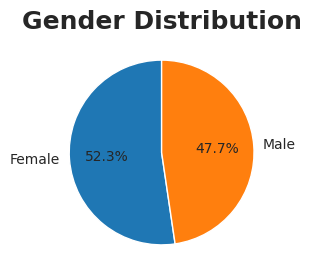

In [ ]:

counts = df['Gender'].value_counts()
plt.figure(figsize=(3,3))
plt.pie(counts, labels=counts.index,autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution', fontsize=18, weight='bold')
plt.show()



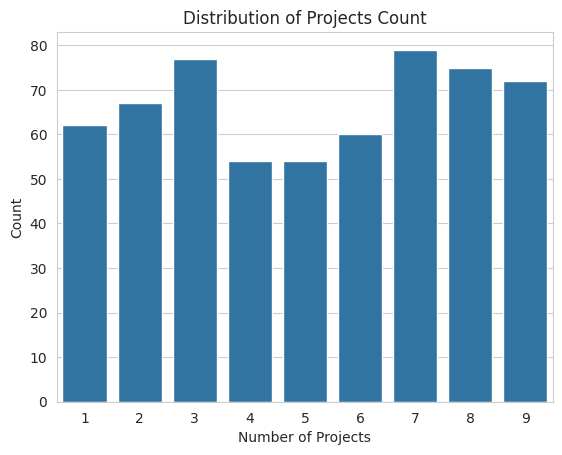

In [ ]:
sns.countplot(x='Projects_Count', data=df)
plt.title('Distribution of Projects Count')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.show()

In [ ]:
(df.head(10))

,Student_ID,Gender,Age,Degree,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Placement_Offer,Salary_Offered_USD
0,1,Male,19,Business,2.56,3,8,0,64,42,57,Yes,8047.08
1,2,Female,27,Engineering,3.66,0,5,2,78,54,40,Yes,3518.56
2,3,Male,26,Data Science,3.73,0,5,1,61,54,49,No,11791.75
3,4,Male,18,Computer Science,2.21,2,8,5,66,42,72,Yes,13946.28
4,5,Male,20,Business,2.59,3,9,2,69,50,53,No,10951.66
5,6,Male,21,Computer Science,3.04,2,4,0,64,74,91,No,19631.72
6,7,Male,25,Data Science,2.42,4,8,4,50,61,65,Yes,14820.55
7,8,Female,28,Data Science,2.48,4,8,2,96,57,50,No,13036.97
8,9,Female,27,Engineering,3.02,0,3,4,49,84,76,Yes,16192.47
9,10,Male,29,Data Science,3.01,2,4,2,70,90,67,No,12022.49


In [ ]:
(df.tail(10))

,Student_ID,Gender,Age,Degree,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Placement_Offer,Salary_Offered_USD
590,591,Female,29,Business,3.85,1,1,0,56,74,76,Yes,19761.43
591,592,Female,19,Engineering,3.28,4,1,0,91,81,94,Yes,15934.35
592,593,Female,22,Arts,2.84,4,1,0,67,52,46,Yes,13398.42
593,594,Female,20,Data Science,2.59,4,3,5,77,59,41,Yes,15098.55
594,595,Female,19,Business,2.78,2,7,3,80,53,64,No,13140.38
595,596,Female,22,Business,2.52,3,9,4,59,45,78,No,14940.13
596,597,Male,19,Data Science,2.86,3,9,1,73,81,63,Yes,8607.62
597,598,Male,28,Data Science,2.71,0,5,0,77,96,82,No,16772.72
598,599,Male,26,Engineering,2.97,3,4,3,50,59,60,No,4159.32
599,600,Female,19,Engineering,2.13,4,6,1,69,69,90,No,11214.65


In [ ]:
(df.describe())

,Student_ID,Age,CGPA,Internships_Count,Projects_Count,Certifications_Count,Technical_Skills_Score_100,Communication_Skills_Score_100,Aptitude_Test_Score_100,Salary_Offered_USD
count,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,23.558333,2.978433,2.01500,5.123333,2.583333,69.380000,68.913333,69.426667,11577.438233
std,173.349358,3.455889,0.584822,1.43697,2.632427,1.713071,17.374658,17.359765,17.769192,4734.794274
min,1.000000,18.000000,2.000000,0.00000,1.000000,0.000000,40.000000,40.000000,40.000000,3127.200000
25%,150.750000,21.000000,2.467500,1.00000,3.000000,1.000000,55.000000,54.000000,54.000000,7348.690000
50%,300.500000,24.000000,2.955000,2.00000,5.000000,3.000000,69.000000,68.000000,69.000000,11763.735000
75%,450.250000,26.000000,3.492500,3.00000,7.000000,4.000000,84.000000,84.000000,86.000000,15551.750000
max,600.000000,29.000000,3.990000,4.00000,9.000000,5.000000,99.000000,99.000000,99.000000,19998.130000


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Degree,0
CGPA,0
Internships_Count,0
Projects_Count,0
Certifications_Count,0
Technical_Skills_Score_100,0
Communication_Skills_Score_100,0


In [ ]:
df.shape

(600, 13)

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Degree', 'CGPA', 'Internships_Count',
       'Projects_Count', 'Certifications_Count', 'Technical_Skills_Score_100',
       'Communication_Skills_Score_100', 'Aptitude_Test_Score_100',
       'Placement_Offer', 'Salary_Offered_USD'],
      dtype='object')

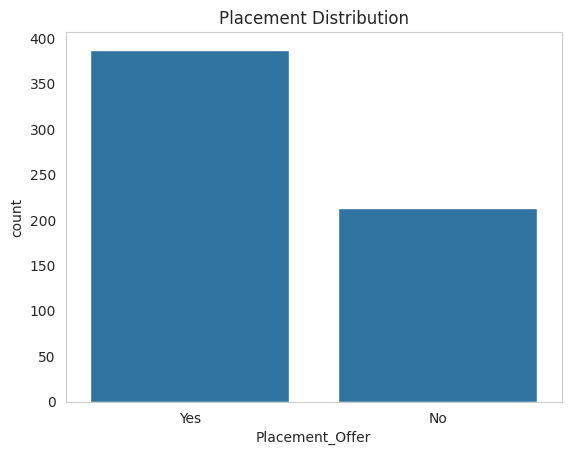

In [ ]:
sns.countplot(x='Placement_Offer', data=df)
plt.title('Placement Distribution')
plt.grid(False)
plt.show()

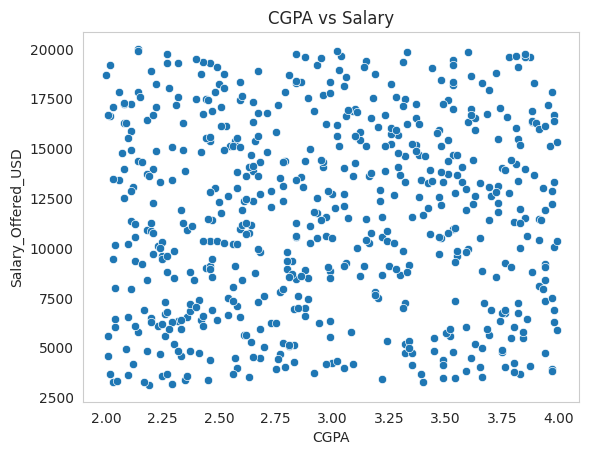

In [ ]:
sns.scatterplot(x='CGPA', y='Salary_Offered_USD', data=df)
plt.title("CGPA vs Salary")
plt.grid(False)
plt.show()

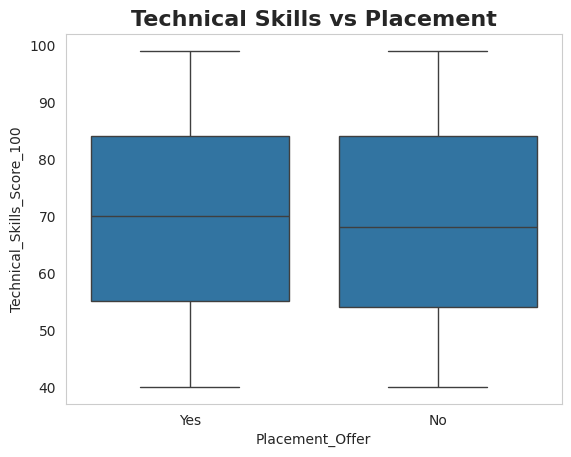

In [ ]:
sns.boxplot(x='Placement_Offer', y='Technical_Skills_Score_100', data=df)
plt.title("Technical Skills vs Placement", fontsize=16, weight='bold')
plt.grid(False)
plt.show()

In [ ]:
X = df.drop(['Placement_Offer','Salary_Offered_USD'], axis=1)
y = df['Placement_Offer']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.625
